In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# add path to utils/
from pathlib import Path
import sys

project_root = Path().resolve().parent
sys.path.append(str(project_root))

# import functions from utils/
from utils.importance_sampling import *
from utils.utility import *
from utils.rejection_sampling import *

from scipy.stats import uniform, norm, cauchy

In [ ]:
# Rejection Sampling Template
def target_density(x):
    """Implements Density Function
    - Input: x (array-like)
    - Output: density value at x
    No need to normalize but should take care of the support.
    e.g. return 0.75 * (1 - x**2) * (x >= -1) * (x <= 1)
    """
    pass

def proposal_density(x):
    """Implements Density Function
    - Input: x (array-like)
    - Output: density value at x
    Usually from stats.distribution.pdf
    e.g. return stats.uniform.pdf(x, loc=-1, scale=2)
    """
    pass

def proposal_rvs():
    """Implements Sampling Function
    - Output: sample from proposal distribution
    Usually from stats.distribution.rvs or np.random.distribution()
    Can handle masking e.g.
    while True:
        sample = np.random.uniform(-1, 1)
        if condition(sample):
            return sample
    """

    pass

M_init: float = 1.0  # Initial guess for M, can be tuned based on the target and proposal distributions
samples, acceptance_rate = rejection_sampling(
    target_density,
    proposal_density,
    proposal_rvs,
    M_init,
    diagnostics=True,
    truncation_q=0.025,
    granularity=1_000,
    n_samples=10_000
)

phi = lambda x: x  # Function to transform samples, such as x > 3
generate_mean_and_std_err([phi(sample) for sample in samples], prob=False)

NameError: name 'rejection_sampling' is not defined

In [ ]:
#q8
n_samples = 10_000_000
sd = 5
x = np.random.normal(0, sd, n_samples)
y = np.random.normal(0, sd, n_samples)

weights = norm.pdf(x) * norm.pdf(y) / norm.pdf(x, loc=0, scale=sd) / norm.pdf(y, loc=0, scale=sd)

samples = (x**3 + y**3 > 100) * 10**5 * weights
generate_mean_and_std_err(samples)

Mean: 0.3664
Standard Error: 0.0010


5000 / 50000 samples accepted.
10000 / 50000 samples accepted.
15000 / 50000 samples accepted.
20000 / 50000 samples accepted.
25000 / 50000 samples accepted.
30000 / 50000 samples accepted.
35000 / 50000 samples accepted.
40000 / 50000 samples accepted.
45000 / 50000 samples accepted.
50000 / 50000 samples accepted.
Acceptance Rate: 0.5278


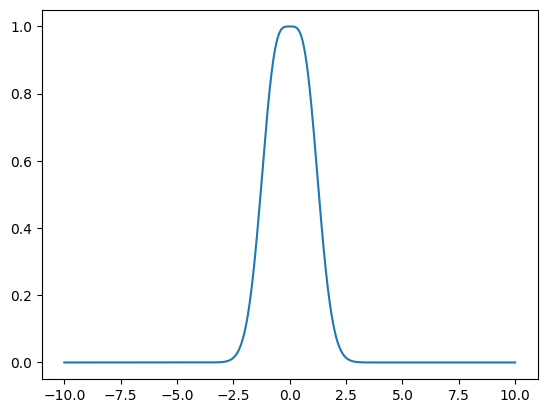

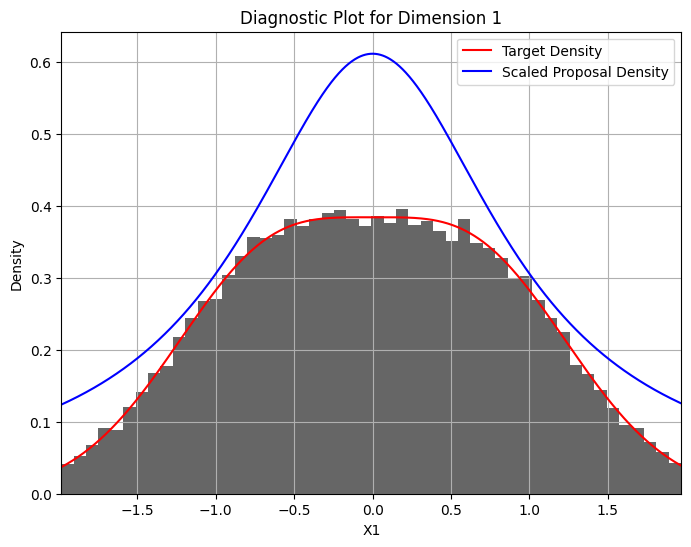

In [13]:
#q7
n_samples = 50_000
target_density = lambda x: (1 + x**2) * np.exp(-x**2)
xx = np.linspace(-10, 10, 1000)
yy = target_density(xx)
plt.plot(xx, yy)

# rejection sampling with cauchy proposal
proposal_density = lambda x: cauchy.pdf(x)
proposal_rvs = lambda : np.random.standard_cauchy(size=(1, 1))
M_init = 5.0

samples, acceptance_rate = rejection_sampling(
    target_density,
    proposal_density,
    proposal_rvs,
    M_init,
    diagnostics=True,
    n_samples=n_samples
)


In [14]:
generate_mean_and_std_err(samples**2)

Mean: 0.8355
Standard Error: 0.0046


In [ ]:
#q6

target_density = lambda x: np.exp(x[0] * x[1])
proposal_density = lambda x: norm.pdf(x, loc=3, scale=0.5) * norm.pdf(x, loc=3, scale=0.5)
def proposal_rvs():
     return 
M_init = np.exp(9)

samples, acceptance_rate = rejection_sampling(
    target_density,
    proposal_density,
    proposal_rvs,
    M_init,
    n_samples=n_samples
)

5000 / 50000 samples accepted.
10000 / 50000 samples accepted.
15000 / 50000 samples accepted.
20000 / 50000 samples accepted.
25000 / 50000 samples accepted.
30000 / 50000 samples accepted.
35000 / 50000 samples accepted.
40000 / 50000 samples accepted.
45000 / 50000 samples accepted.
50000 / 50000 samples accepted.


Acceptance Rate: 0.7012


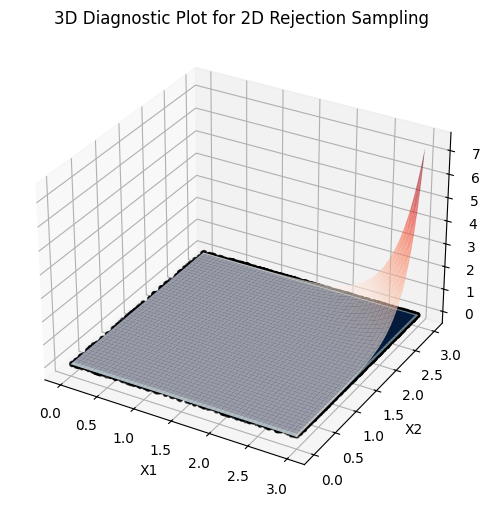

AssertionError: M is too small, target density exceeds scaled proposal density.

In [21]:
diagnostic_plot_2d(samples, acceptance_rate, target_density, proposal_density, M_init)

In [23]:
# q3
n_samples = 50_000
tosses_needed = []
for i in range(n_samples):
    consecutive_heads = 0
    count = 0
    while True:
        count += 1
        toss = np.random.choice([0, 1])
        if toss:
            consecutive_heads += 1
        else:
            consecutive_heads = 0
        
        if consecutive_heads == 3:
            tosses_needed.append(count)
            break

generate_mean_and_std_err(tosses_needed)

Mean: 13.9653
Standard Error: 0.0532


C:\Users\ningc\AppData\Local\Temp\ipykernel_24664\3560645654.py:3: RuntimeWarning: invalid value encountered in log
  inv_cdf = lambda x: 3 * np.sqrt(np.log(1 / (1 - x)))


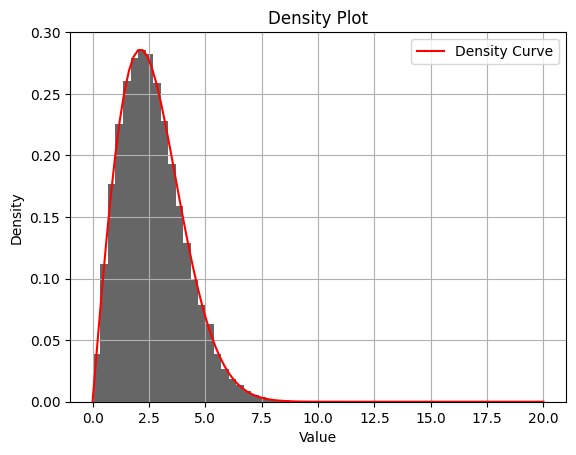

Mean: 2.6516
Standard Error: 0.0062


In [30]:
#q9 (Weibull Distribution)
xx = np.linspace(0, 50, 1000)
inv_cdf = lambda x: 3 * np.sqrt(np.log(1 / (1 - x)))
yy = inv_cdf(xx)

uu = np.random.uniform(0, 1, n_samples)
samples = inv_cdf(uu)

target_density = lambda x: 2/3 * x * np.exp(-(x/3)**2)

plot_density(samples, target_density, x_min=0.0, x_max=20)

generate_mean_and_std_err(samples)


In [32]:
# q5

X = np.random.exponential(scale=0.5, size=n_samples)
samples = 0.5 * np.cos(np.sqrt(X))

generate_mean_and_std_err(samples)

Mean: 0.3852
Standard Error: 0.0005


5000 / 50000 samples accepted.
10000 / 50000 samples accepted.
15000 / 50000 samples accepted.
20000 / 50000 samples accepted.
25000 / 50000 samples accepted.
30000 / 50000 samples accepted.
35000 / 50000 samples accepted.
40000 / 50000 samples accepted.
45000 / 50000 samples accepted.
50000 / 50000 samples accepted.
Acceptance Rate: 0.4341


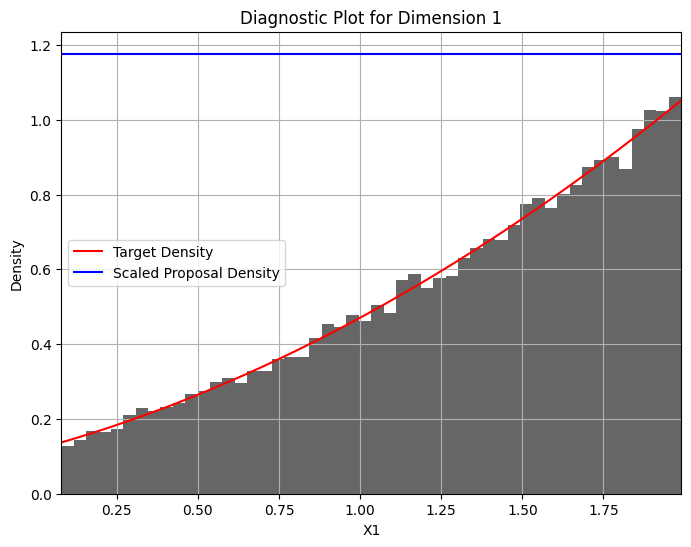

In [35]:
# q11

target_density = lambda x:  (1 + x)**2
proposal_density = lambda x: uniform.pdf(x, loc=0, scale=2)
proposal_rvs = lambda : np.random.uniform(0, 2, size=(1, 1))
M_init = 20.0

samples, acceptance_rate = rejection_sampling(
    target_density,
    proposal_density,
    proposal_rvs,
    M_init,
    diagnostics=True,
    n_samples=n_samples
)


In [36]:
np.std(samples)

np.float64(0.5093936080254209)

In [41]:
# q1
x = np.random.exponential(scale=1/3, size=n_samples)
samples = 2/3 * np.cos(x)

generate_mean_and_std_err(samples)

Mean: 0.6005
Standard Error: 0.0006


2000 / 20000 samples accepted.
4000 / 20000 samples accepted.
6000 / 20000 samples accepted.
8000 / 20000 samples accepted.
10000 / 20000 samples accepted.
12000 / 20000 samples accepted.
14000 / 20000 samples accepted.
16000 / 20000 samples accepted.
18000 / 20000 samples accepted.
20000 / 20000 samples accepted.
Acceptance Rate: 0.2011


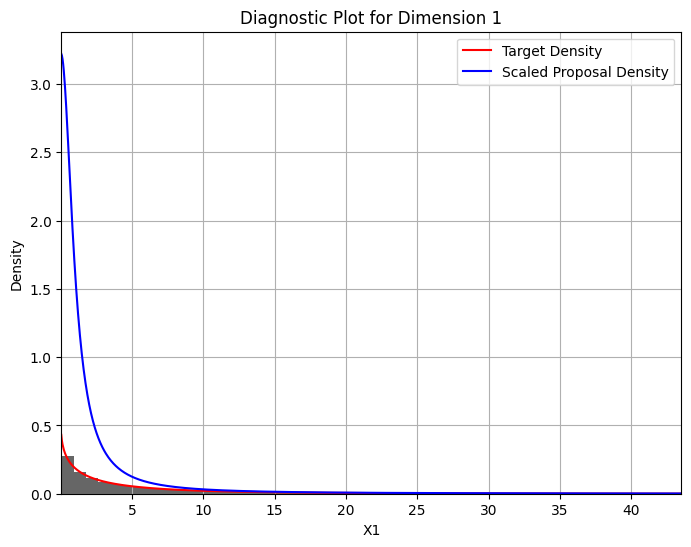

In [ ]:
# q12
target_density = lambda x: np.exp(-np.sqrt(x))
proposal_density = lambda x: cauchy.pdf(x)
def proposal_rvs():
    while True:
        x = np.random.standard_cauchy(size=(1, 1))
        if x >= 0:
            return x
M_init = 20.0

n_samples = 20_000
samples, acceptance_rate = rejection_sampling(
    target_density,
    proposal_density,
    proposal_rvs,
    M_init,
    diagnostics=True,
    n_samples=n_samples
)

5000 / 50000 samples accepted.
10000 / 50000 samples accepted.
15000 / 50000 samples accepted.
20000 / 50000 samples accepted.
25000 / 50000 samples accepted.
30000 / 50000 samples accepted.
35000 / 50000 samples accepted.
40000 / 50000 samples accepted.
45000 / 50000 samples accepted.
50000 / 50000 samples accepted.
Acceptance Rate: 0.3548


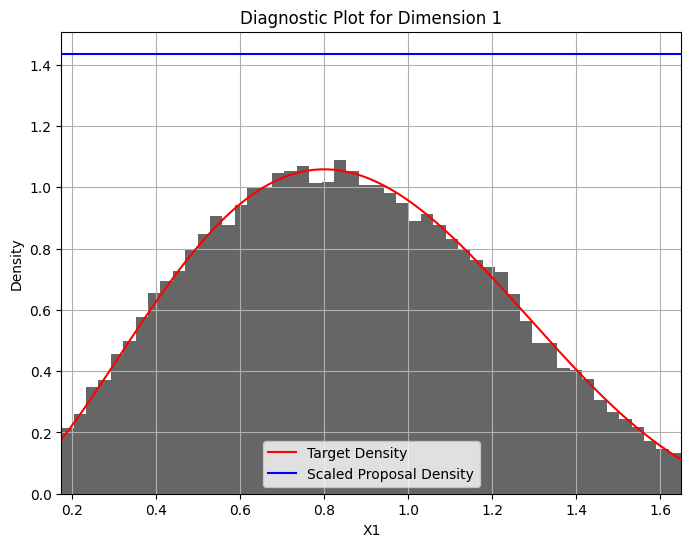

In [49]:
# q10
target_density = lambda x: x**2 * (2 - x)**3
proposal_density = lambda x: uniform.pdf(x, loc=0, scale=2)
def proposal_rvs():
    return uniform.rvs(loc=0, scale=2, size=(1, 1))
M_init = 3.0

n_samples = 50_000
samples, acceptance_rate = rejection_sampling(
    target_density,
    proposal_density,
    proposal_rvs,
    M_init,
    diagnostics=True,
    n_samples=n_samples
)

In [50]:
generate_mean_and_std_err(samples**4)

Mean: 1.1293
Standard Error: 0.0071


In [51]:
xy = np.random.uniform(size=(n_samples, 2))
dists = np.sqrt(np.sum(xy**2, axis=1))
generate_mean_and_std_err(dists)

Mean: 0.7663
Standard Error: 0.0013


In [56]:
# q13
def sample():
    sd = 5
    lamb = 1/5
    x = np.random.exponential(scale=sd, size=5)

    ratio = np.prod(np.exp(-x)) / np.prod(lamb * np.exp(-lamb*x))
    

    sample = 10**4 * (np.sum(x) > 15) * ratio

    return sample

n_samples = 10_000
samples = [sample() for _ in range(n_samples)]

generate_mean_and_std_err(samples)



Mean: 8.4550
Standard Error: 0.2742


In [58]:
# q4
n_samples = 100_000
x = np.random.standard_cauchy(size=n_samples)

samples = np.pi * np.sqrt(5) * np.cos(np.sqrt(5) * x)
generate_mean_and_std_err(samples)

Mean: 0.7448
Standard Error: 0.0156


In [60]:
# q15
r = np.array([5, 2, 1, 3, 1])
w = r / np.sum(r)
ess = 1/ np.sum(w**2)
print(ess)

3.5999999999999996


In [61]:
# q2
k = 10
x = np.random.uniform(0, 1, (n_samples, k))
samples = np.max(x, axis=1)
generate_mean_and_std_err(samples)

Mean: 0.9091
Standard Error: 0.0003


In [75]:
# q20
def sample():
    k = 10
    x = np.random.normal(loc=0.0, scale=3.0, size=k)
    ratio = np.prod(norm.pdf(x) / norm.pdf(x, loc=0.0, scale=3.0))
    s = 10**5 * (np.sum(x**2) > 30) * ratio
    return s

n_samples = 50_000
samples = [sample() for i in range(n_samples)] 
generate_mean_and_std_err(samples)

Mean: 85.0575
Standard Error: 2.7049


In [70]:
from scipy.stats import chi2
(1 - chi2.cdf(30, df=10)) * 10**5

np.float64(85.6641210775333)

In [92]:
# q14
n_samples = 100_000
Z = np.random.normal(1.0, 1.0, (n_samples, 10))
ratios = np.prod(norm.pdf(Z) / norm.pdf(Z, loc=1.0, scale=1.0), axis=1)
walk = np.hstack([np.zeros(shape=(n_samples,1)), np.cumsum(Z, axis=1)])
samples = 10**4 * np.all(walk >= np.arange(0, 11, 1), axis=1) * ratios
generate_mean_and_std_err(samples)


Mean: 1.4778
Standard Error: 0.0197


In [102]:
n_samples = 1_000_000
k = 20
Z = np.random.choice([-1, 1],  size=(n_samples, k), p=[0.3, 0.7])
ratios = np.prod(np.where(Z == -1, 0.5 / 0.3, 0.5 / 0.7), axis=1)
walk = np.hstack([np.zeros(shape=(n_samples,1)), np.cumsum(Z, axis=1)])
samples = 10**4 * (walk[:, k] >= 14) * ratios
generate_mean_and_std_err(samples)

Mean: 12.8546
Standard Error: 0.0401


In [110]:

n_samples = 100_000
f = lambda x: np.exp(-np.sqrt(np.abs(x)))

# 1. Samples from Cauchy
samples = np.random.standard_cauchy(n_samples)

# 2. Proposal Density q(x) 
# Note: np.random.standard_cauchy is the "Standard" version (loc=0, scale=1)
q_x = 1 / (np.pi * (1 + samples**2))

# 3. Unnormalized Weights
unnorm_w = f(samples) / q_x

# 4. The Integral Estimate (Normalizing Constant)
Z_hat = np.mean(unnorm_w)
print(f"Estimated Normalizing Constant Z: {Z_hat}")

Estimated Normalizing Constant Z: 3.9894635199283983


In [ ]:
2 * 